# Projeto: Precificação de Imóveis - King County

**Variável-alvo:** `price`

**Objetivo de negócio:** Estimar o valor de venda de imóveis no condado de 
King County (EUA) a partir de características físicas e de localização, 
para apoiar decisões de compra, venda ou financiamento.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/kc_house_data.csv")


In [6]:
df.shape

(21613, 21)

In [7]:
df.dtypes

id                 int64
date                 str
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

# O que notei nessa etapa abaixo:
1. **Valores ausentes em sqft_above:** No count da tabela: a maioria das colunas tem 21613, mas sqft_above mostra 21611. Isso indica 2 valores ausentes nessa coluna — é algo que irei precisar tratar na Fase 2 (Data Prep).
2. **Outlier claro em bedrooms:** O max de bedrooms é 33.000000 — 33 quartos é, provavelmente, um erro de digitação ou anomalia (provavelmente era pra ser 3), não um imóvel real.
3. **date está como str/object**. Precisarei corrigir isso nas próximas etapas.

In [8]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21611.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.396095,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.128162,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


**Gráfico de Distribuição do preço dos imóveis:**

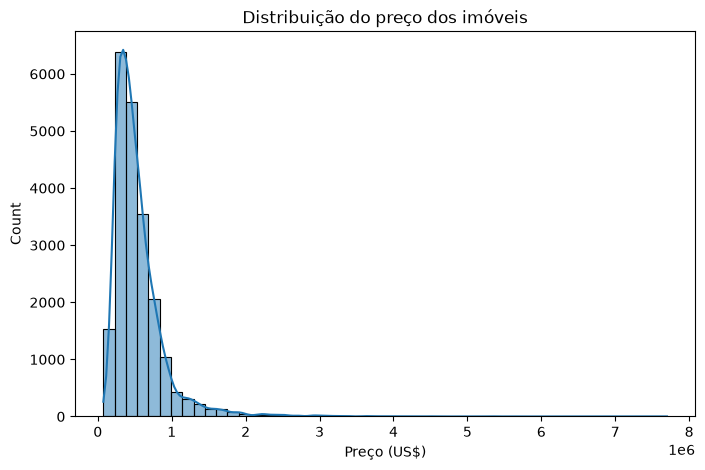

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("Distribuição do preço dos imóveis")
plt.xlabel("Preço (US$)")
plt.savefig("../outputs/figures/hist_price.png")
plt.show()

**Gráfico da Área Construida X Preço**

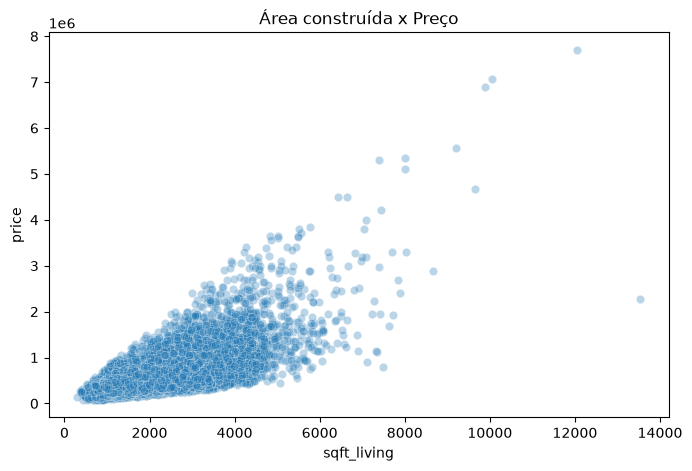

In [10]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["sqft_living"], y=df["price"], alpha=0.3)
plt.title("Área construída x Preço")
plt.savefig("../outputs/figures/scatter_sqftliving_price.png")
plt.show()